In [3]:
# ===========================================
# STEP 2: DATA CLEANING
# Temperature Prediction ML Project
# ===========================================

# Import Libraries
import pandas as pd
import numpy as np

# -------------------------------------------
# Load Dataset
# -------------------------------------------
df = pd.read_excel("messy_temperature_dataset.xlsx")

print("Dataset Loaded Successfully!")

# -------------------------------------------
# Display Basic Information
# -------------------------------------------
print("\nFirst 5 Rows:")
print(df.head())

print("\nDataset Shape:")
print(df.shape)

print("\nColumn Names:")
print(df.columns)

print("\nDataset Information:")
print(df.info())

print("\nStatistical Summary:")
print(df.describe(include='all'))

# -------------------------------------------
# Check Missing Values
# -------------------------------------------
print("\nMissing Values Before Cleaning:")
print(df.isnull().sum())

# -------------------------------------------
# Fill Missing Values
# -------------------------------------------

# Numerical Columns
num_cols = df.select_dtypes(include=['number']).columns

for col in num_cols:
    df[col].fillna(df[col].mean(), inplace=True)

# Categorical Columns
cat_cols = df.select_dtypes(include=['object']).columns

for col in cat_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

print("\nMissing Values After Cleaning:")
print(df.isnull().sum())

# -------------------------------------------
# Remove Duplicate Rows
# -------------------------------------------
duplicates = df.duplicated().sum()
print("\nDuplicate Rows Before Removal:", duplicates)

df = df.drop_duplicates()

print("Duplicate Rows After Removal:", df.duplicated().sum())

# -------------------------------------------
# Convert Date Column (If Available)
# -------------------------------------------
if 'Date' in df.columns:
    df['Date'] = pd.to_datetime(df['Date'], errors='coerce')

# -------------------------------------------
# Remove Outliers Using IQR Method
# -------------------------------------------
numeric_columns = df.select_dtypes(include=np.number).columns

for column in numeric_columns:

    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df = df[(df[column] >= lower) & (df[column] <= upper)]

print("\nDataset Shape After Removing Outliers:")
print(df.shape)

# -------------------------------------------
# Final Dataset Information
# -------------------------------------------
print("\nFinal Dataset Information:")
print(df.info())

print("\nFinal Missing Values:")
print(df.isnull().sum())

print("\nFinal Dataset Shape:")
print(df.shape)

# -------------------------------------------
# Save Cleaned Dataset
# -------------------------------------------
output_file = "cleaned_temperature_dataset.xlsx"

df.to_excel(output_file, index=False)

print("\n===================================")
print("Data Cleaning Completed Successfully!")
print("Cleaned Dataset Saved As:", output_file)
print("===================================")

# -------------------------------------------
# Display First 10 Rows
# -------------------------------------------
print("\nCleaned Dataset Preview:")
print(df.head(10))

Dataset Loaded Successfully!

First 5 Rows:
   Day  Month    Year  Hour  Humidity  WindSpeed  Pressure  Rainfall  \
0    4    NaN     NaN     0        65          7      1002       1.1   
1    3    9.0  2026.0    18        34          0       997       2.7   
2   20    9.0  2026.0     0        55         22      1015       1.4   
3   26    5.0  2026.0     0        50         22      1008       0.0   
4    7    3.0  2026.0    15        43          2      1007       3.7   

   Temperature  
0         16.0  
1         29.7  
2         19.5  
3         23.5  
4         32.4  

Dataset Shape:
(1003, 9)

Column Names:
Index(['Day', 'Month', 'Year', 'Hour', 'Humidity', 'WindSpeed', 'Pressure',
       'Rainfall', 'Temperature'],
      dtype='object')

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1003 entries, 0 to 1002
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Day          1003 non-null   i

/tmp/ipykernel_2832/2585272835.py:49: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mean(), inplace=True)


Dataset Loaded Successfully!

First 5 Rows
   Day     Month  Year  Hour  Humidity  WindSpeed  Pressure  Rainfall  \
0    4  6.752257  2026     0        65          7      1002       1.1   
1    3  9.000000  2026    18        34          0       997       2.7   
2   20  9.000000  2026     0        55         22      1015       1.4   
3   26  5.000000  2026     0        50         22      1008       0.0   
4    7  3.000000  2026    15        43          2      1007       3.7   

   Temperature  
0         16.0  
1         29.7  
2         19.5  
3         23.5  
4         32.4  

Last 5 Rows
     Day  Month  Year  Hour  Humidity  WindSpeed  Pressure  Rainfall  \
974   15    8.0  2026     0        34          5      1012       0.1   
975   16    3.0  2026    18        47          9      1017       0.0   
976   19    2.0  2026    21        90         15      1012       1.9   
977   19    8.0  2026    18        75         24      1004       0.1   
978    9   12.0  2026     6        94      

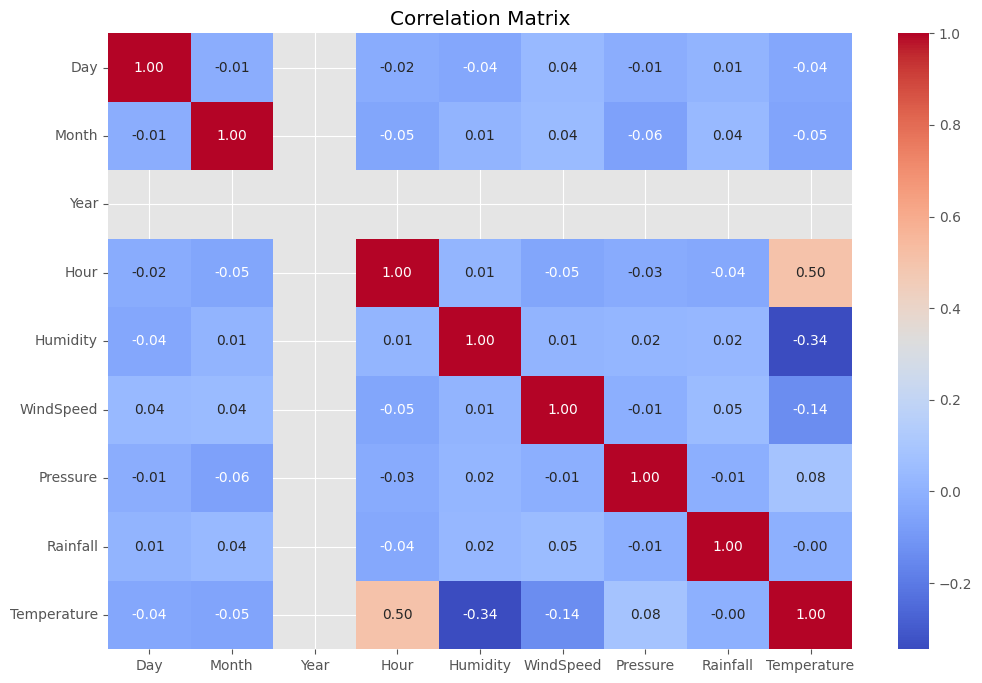

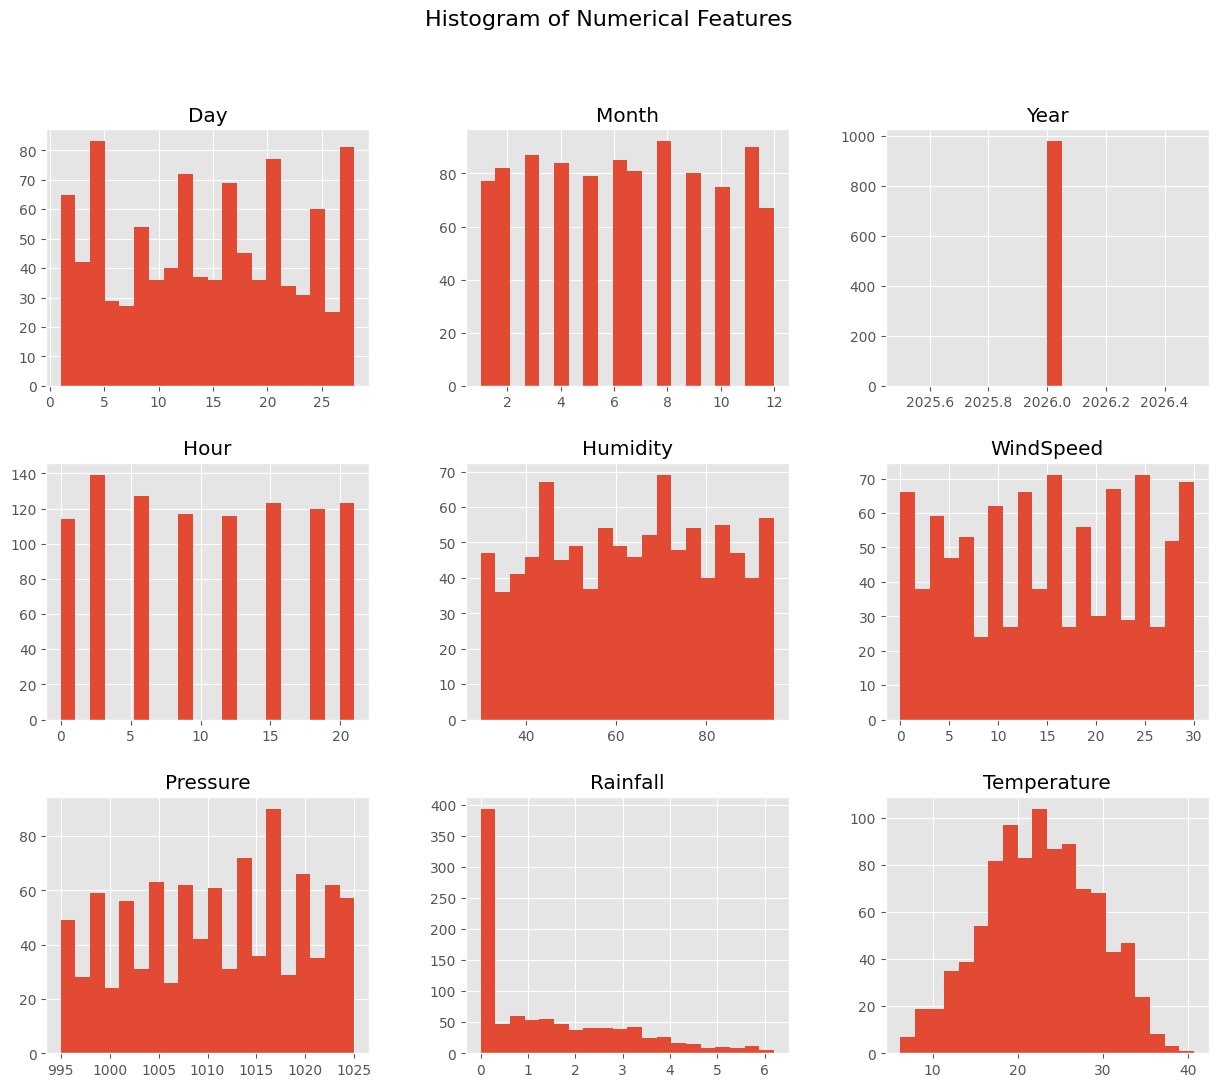

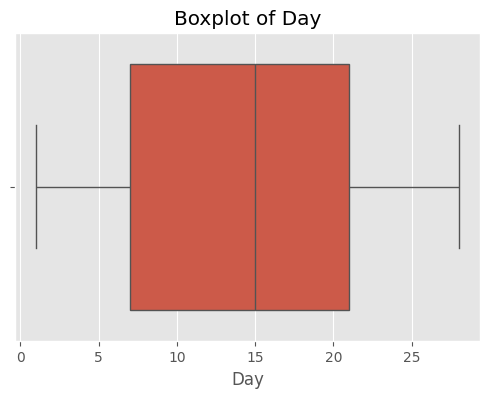

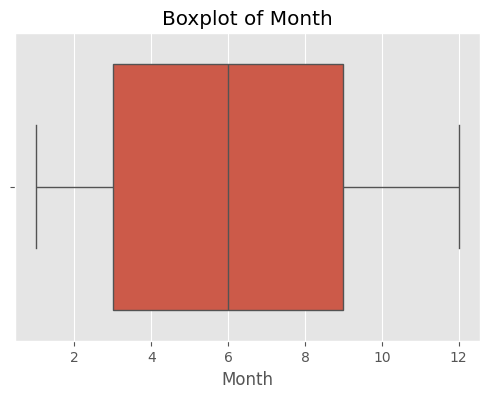

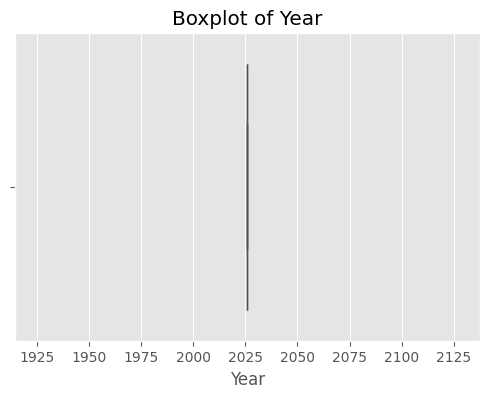

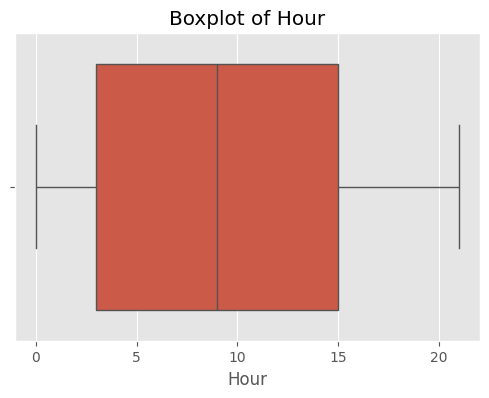

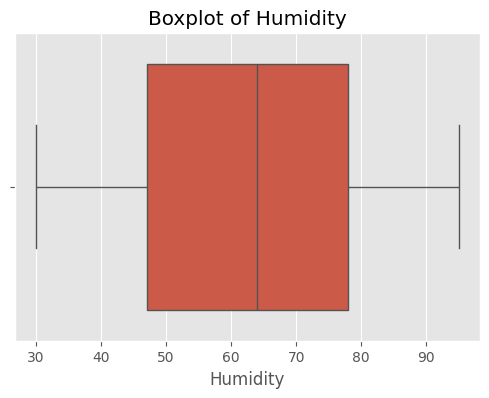

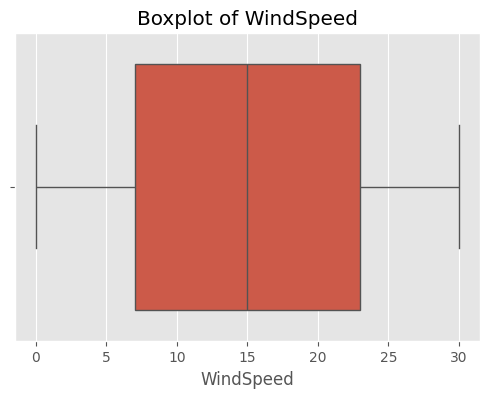

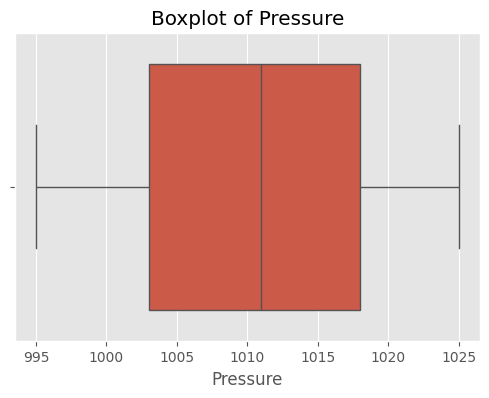

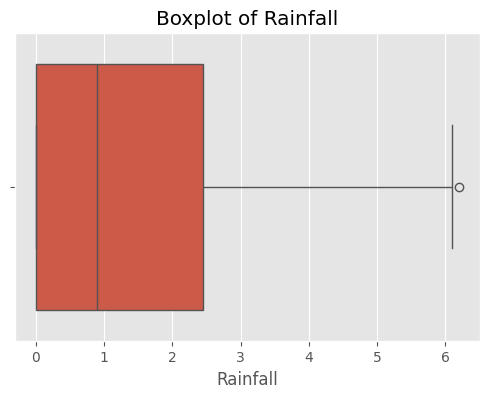

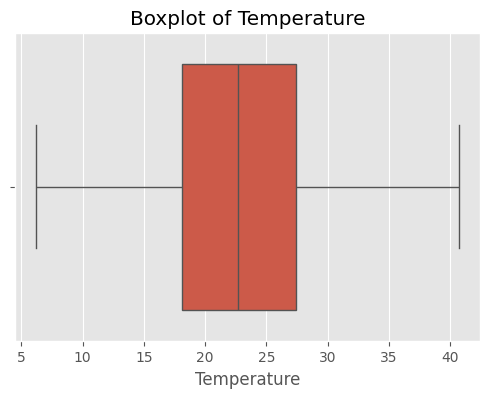

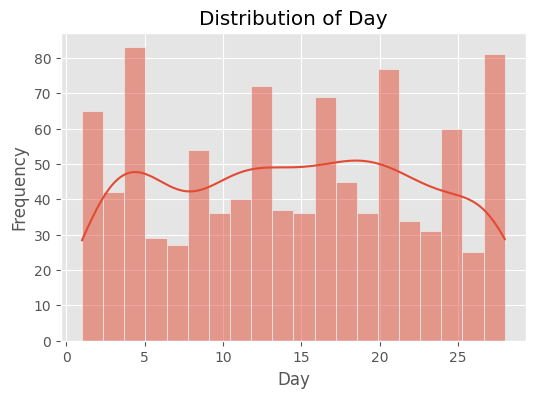

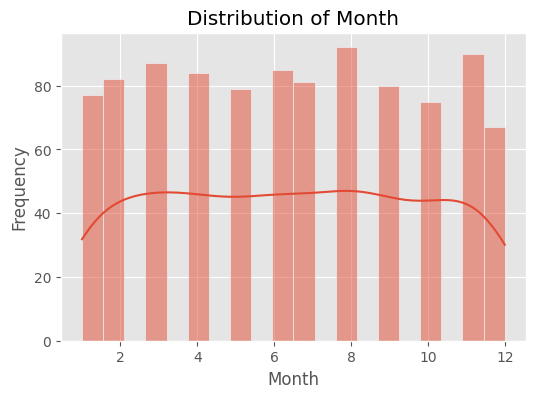

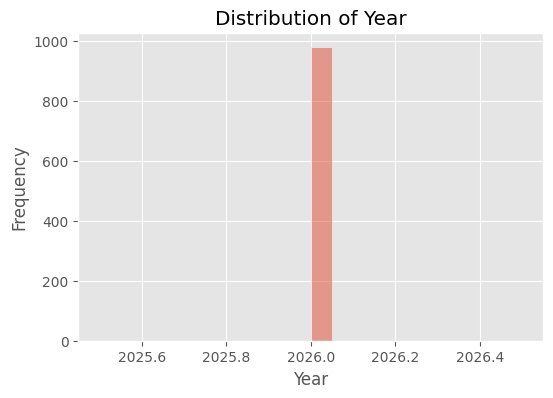

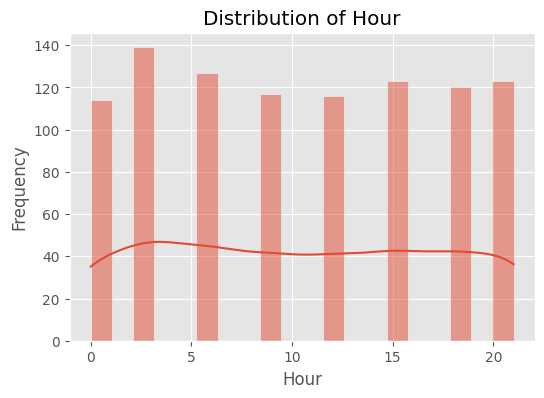

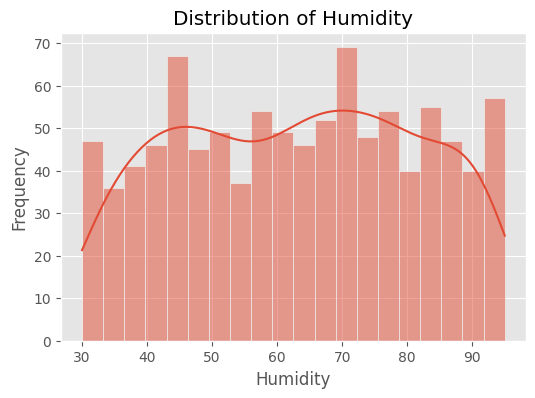

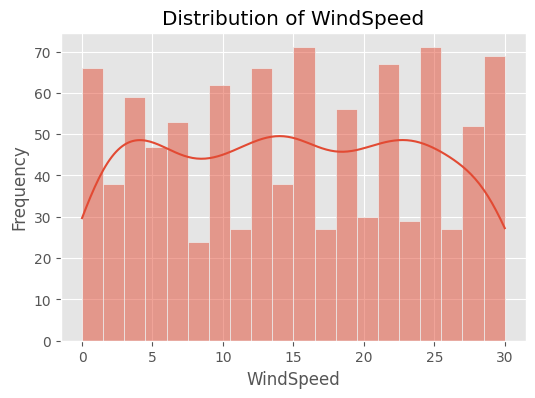

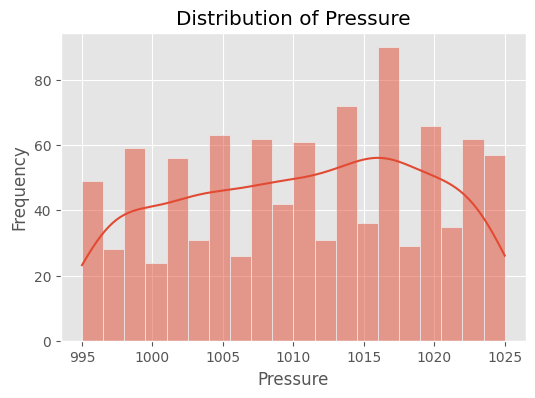

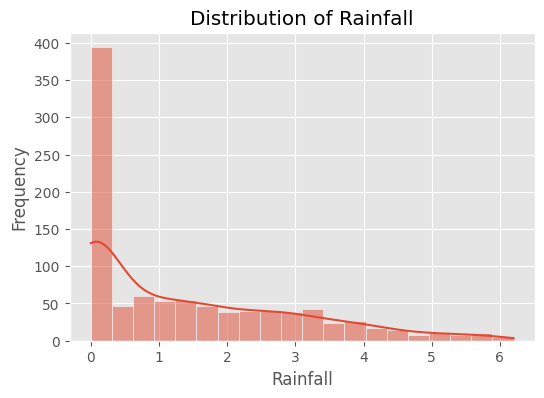

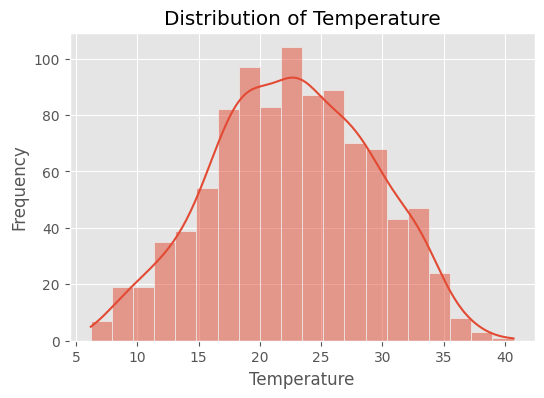

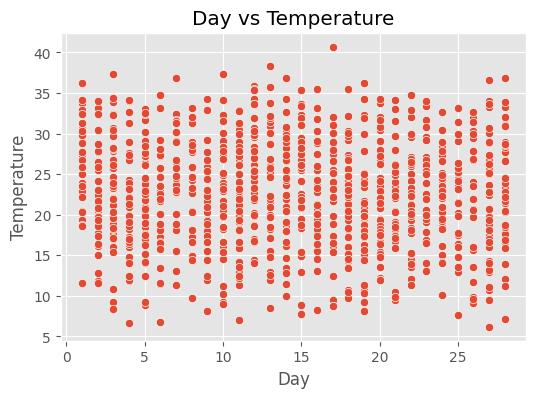

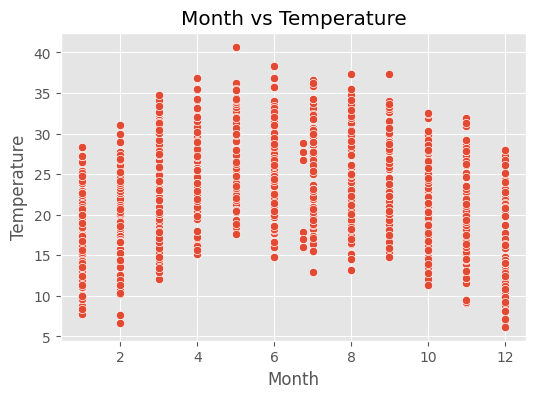

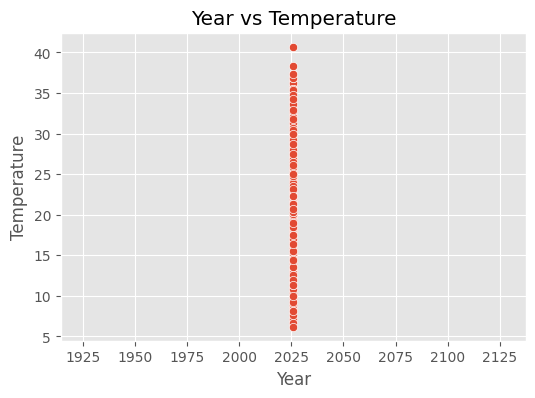

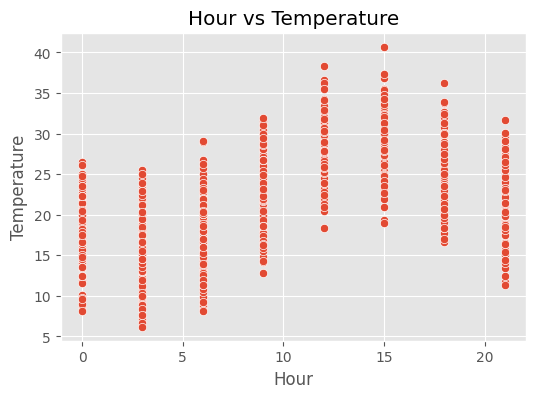

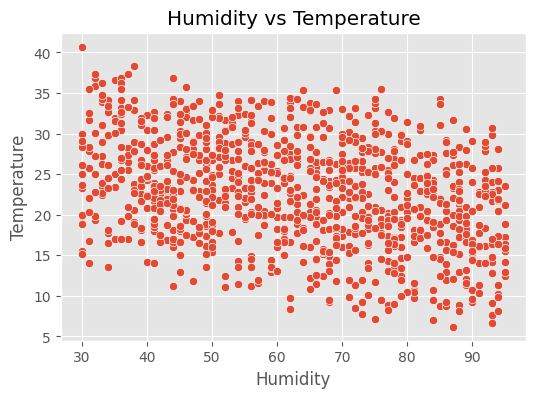

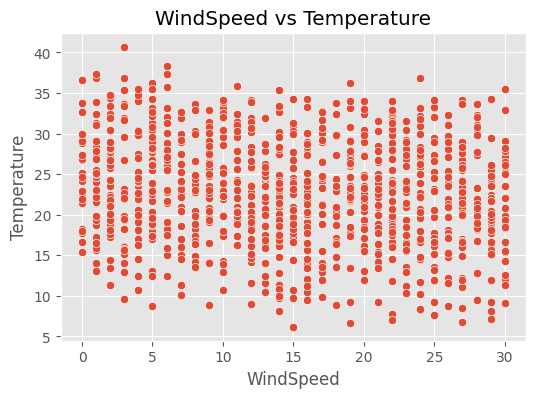

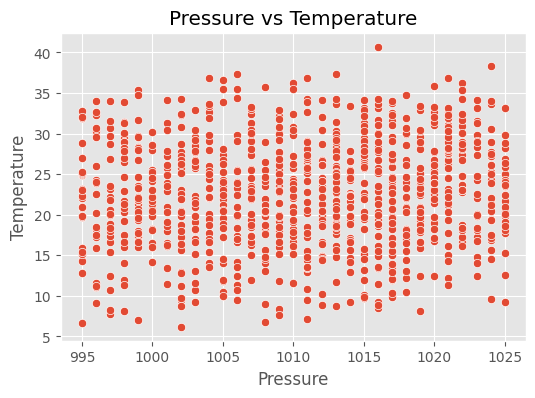

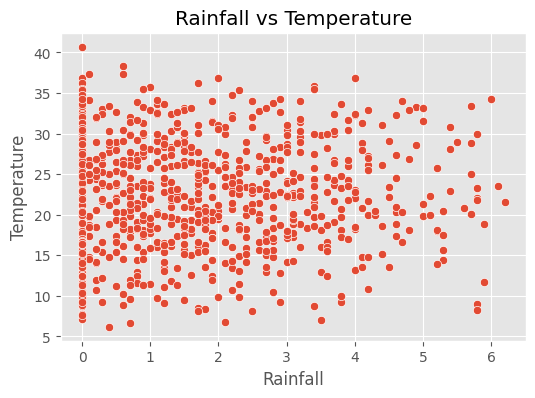

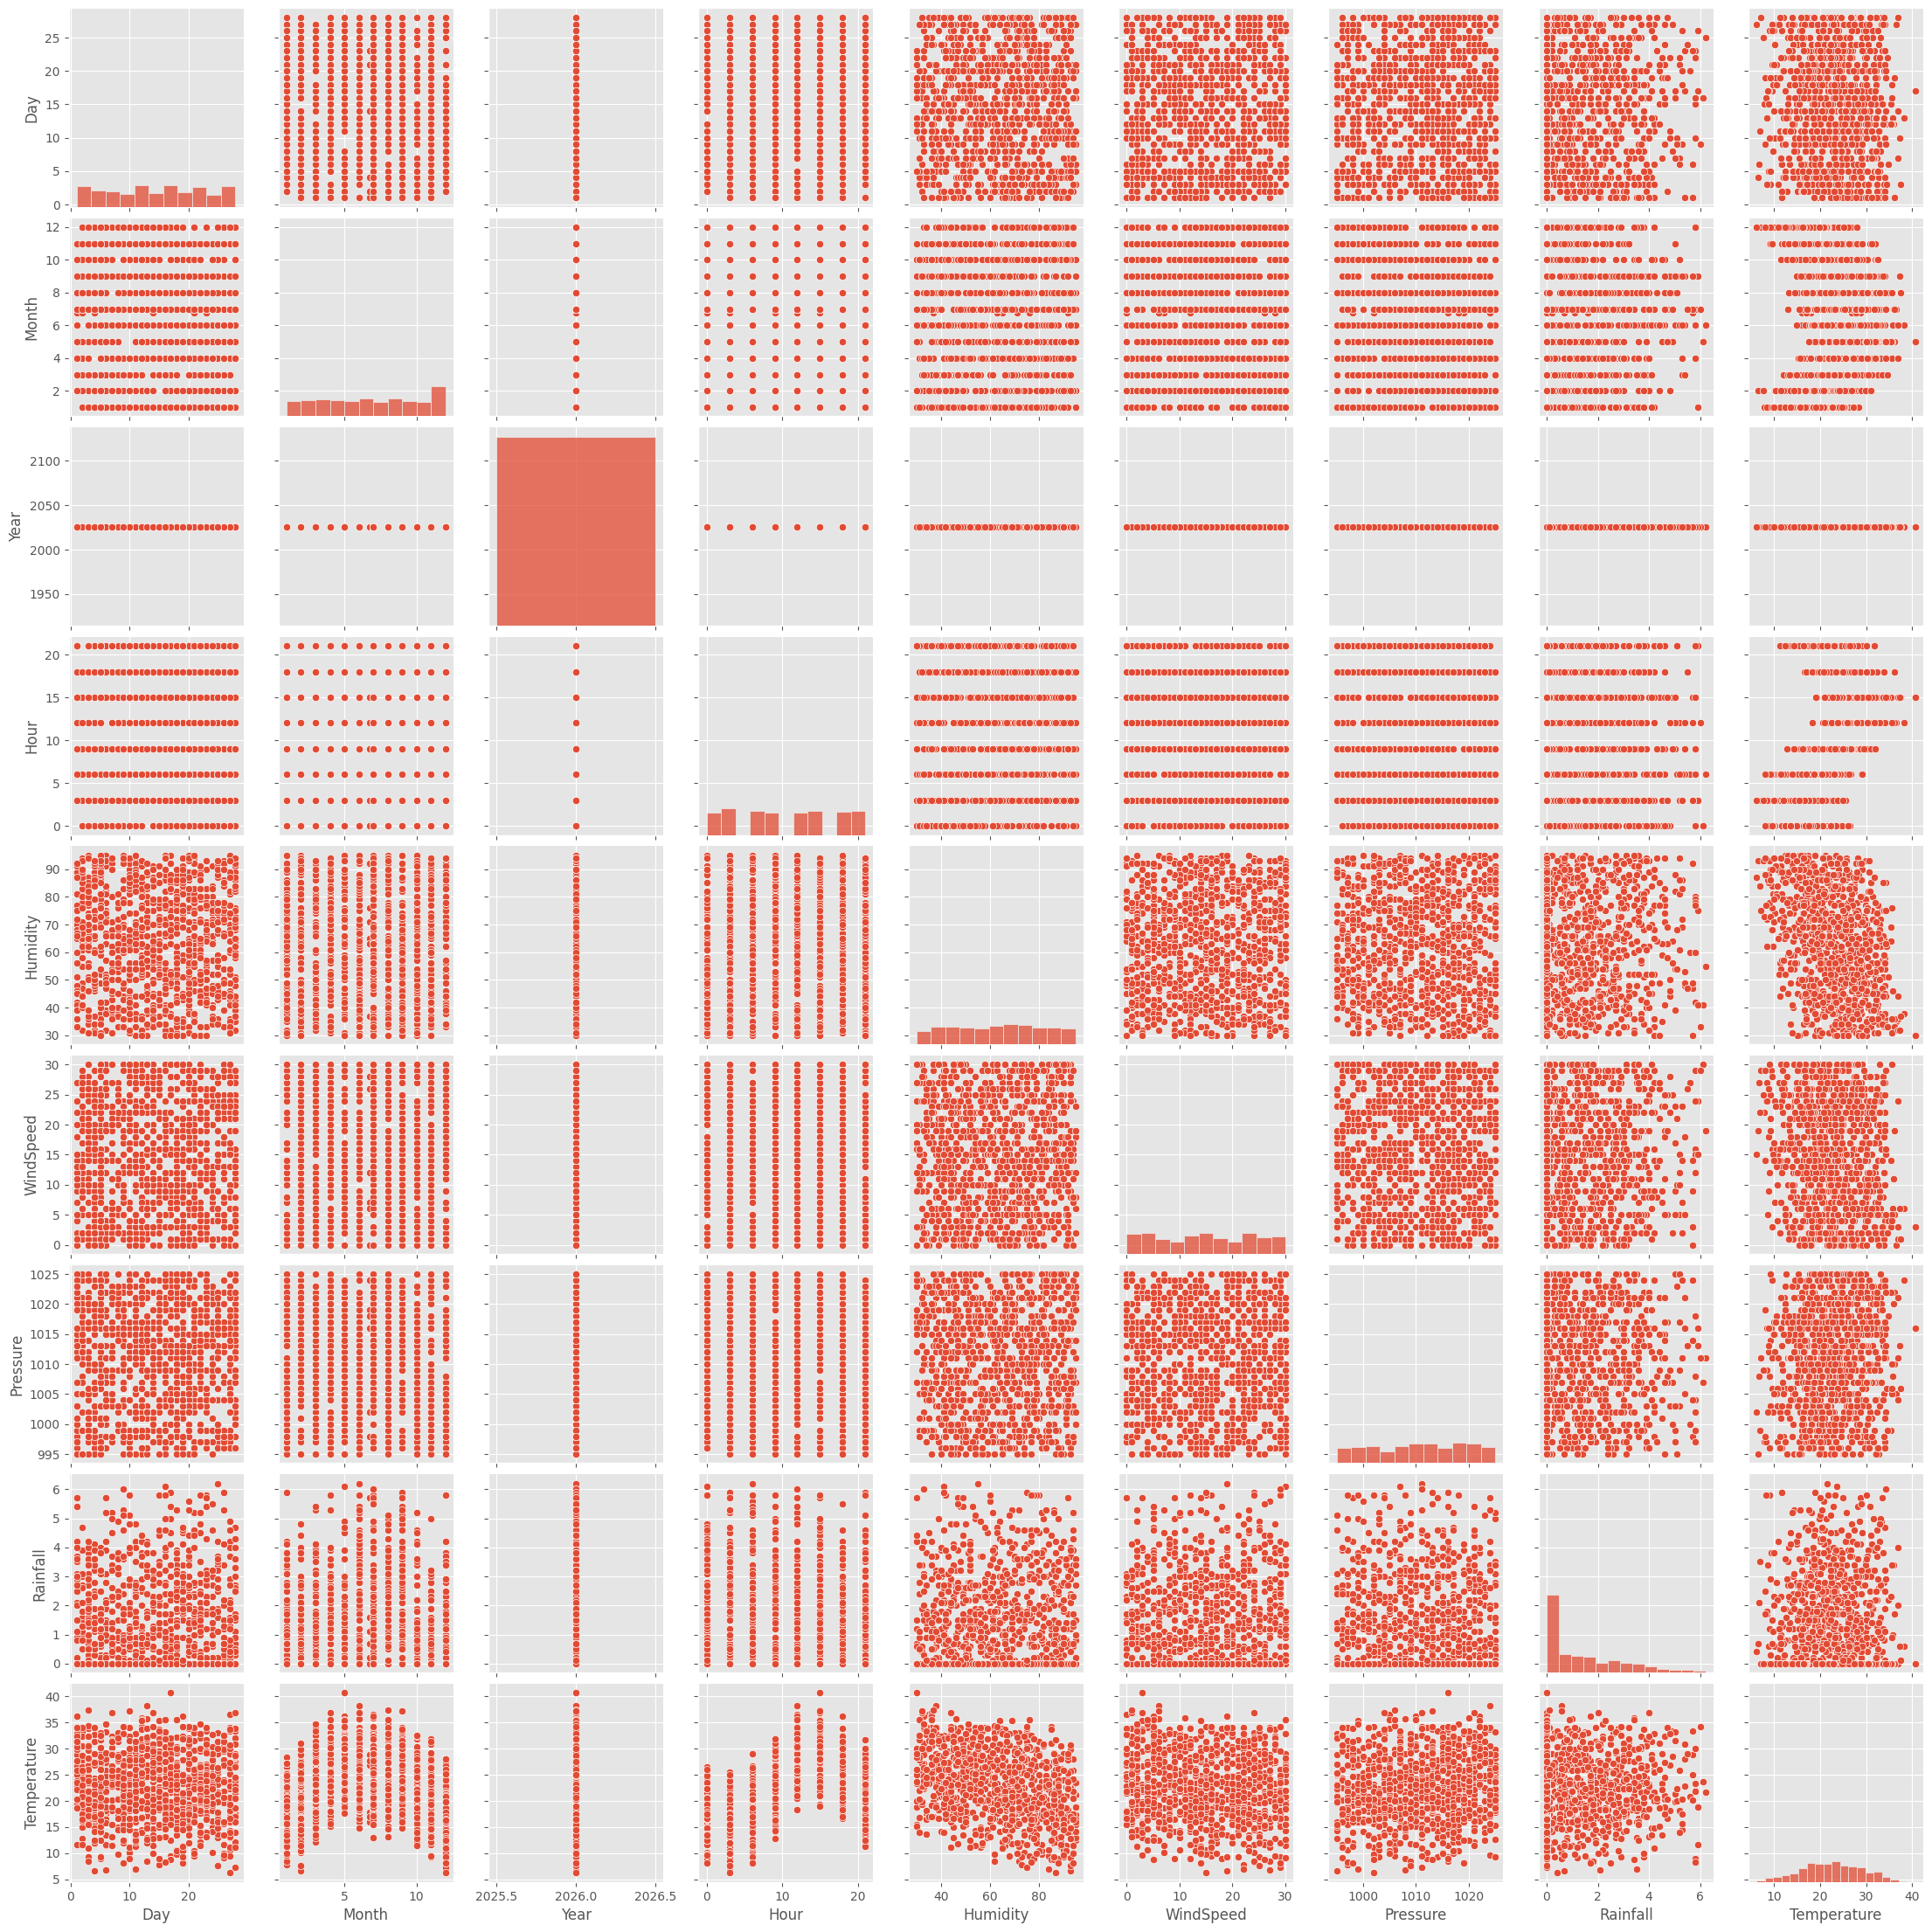


Correlation with Temperature
Temperature    1.000000
Hour           0.504606
Pressure       0.084963
Rainfall      -0.003485
Day           -0.044632
Month         -0.054135
WindSpeed     -0.136131
Humidity      -0.344484
Year                NaN
Name: Temperature, dtype: float64

Average Temperature: 22.62155260469867
Maximum Temperature: 40.7
Minimum Temperature: 6.2
Median Temperature: 22.7
Standard Deviation: 6.508183871146796

Correlation matrix saved as correlation_matrix.csv

EDA Completed Successfully


In [4]:
# ===========================================
# EXPLORATORY DATA ANALYSIS (EDA)
# Temperature Prediction ML Project
# ===========================================

# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set plot style
plt.style.use('ggplot')

# -------------------------------------------
# Load Cleaned Dataset
# -------------------------------------------
df = pd.read_excel("cleaned_temperature_dataset.xlsx")

print("Dataset Loaded Successfully!")

# -------------------------------------------
# Basic Information
# -------------------------------------------
print("\nFirst 5 Rows")
print(df.head())

print("\nLast 5 Rows")
print(df.tail())

print("\nDataset Shape")
print(df.shape)

print("\nColumn Names")
print(df.columns.tolist())

print("\nData Types")
print(df.dtypes)

print("\nDataset Information")
df.info()

print("\nStatistical Summary")
print(df.describe())

# -------------------------------------------
# Missing Values
# -------------------------------------------
print("\nMissing Values")
print(df.isnull().sum())

# -------------------------------------------
# Duplicate Values
# -------------------------------------------
print("\nDuplicate Rows:", df.duplicated().sum())

# -------------------------------------------
# Correlation Matrix
# -------------------------------------------
numeric_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(12,8))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

# -------------------------------------------
# Histograms
# -------------------------------------------
numeric_df.hist(figsize=(15,12), bins=20)
plt.suptitle("Histogram of Numerical Features", fontsize=16)
plt.show()

# -------------------------------------------
# Boxplots
# -------------------------------------------
for column in numeric_df.columns:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=df[column])
    plt.title(f"Boxplot of {column}")
    plt.show()

# -------------------------------------------
# Distribution Plots
# -------------------------------------------
for column in numeric_df.columns:
    plt.figure(figsize=(6,4))
    sns.histplot(df[column], kde=True, bins=20)
    plt.title(f"Distribution of {column}")
    plt.xlabel(column)
    plt.ylabel("Frequency")
    plt.show()

# -------------------------------------------
# Scatter Plots with Temperature
# -------------------------------------------
if "Temperature" in df.columns:

    features = [col for col in numeric_df.columns if col != "Temperature"]

    for feature in features:
        plt.figure(figsize=(6,4))
        sns.scatterplot(data=df, x=feature, y="Temperature")
        plt.title(f"{feature} vs Temperature")
        plt.show()

# -------------------------------------------
# Pair Plot
# -------------------------------------------
sns.pairplot(numeric_df)
plt.show()

# -------------------------------------------
# Count Plot for Categorical Columns
# -------------------------------------------
categorical_columns = df.select_dtypes(include='object').columns

for column in categorical_columns:
    plt.figure(figsize=(8,5))
    sns.countplot(x=df[column])
    plt.xticks(rotation=45)
    plt.title(f"Count Plot of {column}")
    plt.show()

# -------------------------------------------
# Correlation with Temperature
# -------------------------------------------
if "Temperature" in numeric_df.columns:

    corr = numeric_df.corr()["Temperature"].sort_values(ascending=False)

    print("\nCorrelation with Temperature")
    print(corr)

# -------------------------------------------
# Average Temperature
# -------------------------------------------
if "Temperature" in df.columns:

    print("\nAverage Temperature:", df["Temperature"].mean())
    print("Maximum Temperature:", df["Temperature"].max())
    print("Minimum Temperature:", df["Temperature"].min())
    print("Median Temperature:", df["Temperature"].median())
    print("Standard Deviation:", df["Temperature"].std())

# -------------------------------------------
# Line Plot (If Date Exists)
# -------------------------------------------
if "Date" in df.columns:

    df["Date"] = pd.to_datetime(df["Date"])

    plt.figure(figsize=(12,5))
    plt.plot(df["Date"], df["Temperature"])
    plt.title("Temperature Over Time")
    plt.xlabel("Date")
    plt.ylabel("Temperature")
    plt.xticks(rotation=45)
    plt.show()

# -------------------------------------------
# Save Correlation Matrix
# -------------------------------------------
corr_matrix = numeric_df.corr()
corr_matrix.to_csv("correlation_matrix.csv")

print("\nCorrelation matrix saved as correlation_matrix.csv")

print("\n========================================")
print("EDA Completed Successfully")
print("========================================")

In [5]:
# ===========================================
# STEP 4: FEATURE SELECTION & TRAIN-TEST SPLIT
# Temperature Prediction ML Project
# ===========================================

# Import Libraries
import pandas as pd
from sklearn.model_selection import train_test_split

# -------------------------------------------
# Load Cleaned Dataset
# -------------------------------------------
df = pd.read_excel("cleaned_temperature_dataset.xlsx")

print("Dataset Loaded Successfully!")

# -------------------------------------------
# Display Column Names
# -------------------------------------------
print("\nColumns in Dataset:")
print(df.columns.tolist())

# -------------------------------------------
# Convert Date Column (if available)
# -------------------------------------------
if 'Date' in df.columns:
    df['Date'] = pd.to_datetime(df['Date'])
    df['Year'] = df['Date'].dt.year
    df['Month'] = df['Date'].dt.month
    df['Day'] = df['Date'].dt.day
    df.drop('Date', axis=1, inplace=True)

# -------------------------------------------
# Separate Features and Target
# -------------------------------------------
X = df.drop("Temperature", axis=1)
y = df["Temperature"]

print("\nFeatures (X):")
print(X.head())

print("\nTarget (y):")
print(y.head())

# -------------------------------------------
# Convert Categorical Columns to Numeric
# -------------------------------------------
X = pd.get_dummies(X, drop_first=True)

print("\nFeatures After Encoding:")
print(X.head())

# -------------------------------------------
# Train-Test Split
# -------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

# -------------------------------------------
# Display Shapes
# -------------------------------------------
print("\nTraining Features Shape :", X_train.shape)
print("Testing Features Shape  :", X_test.shape)

print("\nTraining Target Shape :", y_train.shape)
print("Testing Target Shape  :", y_test.shape)

print("\n===================================")
print("Feature Selection Completed")
print("Train-Test Split Completed")
print("===================================")

Dataset Loaded Successfully!

Columns in Dataset:
['Day', 'Month', 'Year', 'Hour', 'Humidity', 'WindSpeed', 'Pressure', 'Rainfall', 'Temperature']

Features (X):
   Day     Month  Year  Hour  Humidity  WindSpeed  Pressure  Rainfall
0    4  6.752257  2026     0        65          7      1002       1.1
1    3  9.000000  2026    18        34          0       997       2.7
2   20  9.000000  2026     0        55         22      1015       1.4
3   26  5.000000  2026     0        50         22      1008       0.0
4    7  3.000000  2026    15        43          2      1007       3.7

Target (y):
0    16.0
1    29.7
2    19.5
3    23.5
4    32.4
Name: Temperature, dtype: float64

Features After Encoding:
   Day     Month  Year  Hour  Humidity  WindSpeed  Pressure  Rainfall
0    4  6.752257  2026     0        65          7      1002       1.1
1    3  9.000000  2026    18        34          0       997       2.7
2   20  9.000000  2026     0        55         22      1015       1.4
3   26  5.00000

In [8]:
# ===========================================
# STEP 5: MODEL TRAINING USING DECISION TREE REGRESSOR
# Temperature Prediction ML Project
# ===========================================

# Import Required Libraries
import pandas as pd
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score

# -------------------------------------------
# Create Decision Tree Regressor Model
# -------------------------------------------
model = DecisionTreeRegressor(
    criterion='squared_error',
    max_depth=10,
    random_state=42
)

# -------------------------------------------
# Train the Model
# -------------------------------------------
model.fit(X_train, y_train)

print("==========================================")
print("Decision Tree Regressor Model Trained Successfully!")
print("==========================================")

# -------------------------------------------
# Predict Temperature
# -------------------------------------------
y_pred = model.predict(X_test)

# -------------------------------------------
# Compare Actual vs Predicted Values
# -------------------------------------------
results = pd.DataFrame({
    "Actual Temperature": y_test.values,
    "Predicted Temperature": y_pred
})

print("\nFirst 10 Predictions:")
print(results.head(10))

# -------------------------------------------
# Calculate R² Score
# -------------------------------------------
r2 = r2_score(y_test, y_pred)

print(f"\nR² Score : {r2:.4f}")

# -------------------------------------------
# Calculate Accuracy Percentage
# -------------------------------------------
accuracy = r2 * 100

print(f"Model Accuracy : {accuracy:.2f}%")

# -------------------------------------------
# Display Feature Importance
# -------------------------------------------
feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print("\nFeature Importance:")
print(feature_importance)

# -------------------------------------------
# Save Prediction Results
# -------------------------------------------
results.to_excel("temperature_predictions.xlsx", index=False)

print("\nPrediction results saved as 'temperature_predictions.xlsx'")

print("\n==========================================")
print("Model Training Completed Successfully!")
print("==========================================")

Decision Tree Regressor Model Trained Successfully!

First 10 Predictions:
   Actual Temperature  Predicted Temperature
0                15.7              12.900000
1                11.6              14.700000
2                30.4              28.600000
3                29.0              28.600000
4                17.8              18.400000
5                33.4              32.648148
6                26.2              29.300000
7                18.3              20.800000
8                21.8              19.900000
9                26.9              29.708333

R² Score : 0.8447
Model Accuracy : 84.47%

Feature Importance:
     Feature  Importance
3       Hour    0.571585
1      Month    0.271972
4   Humidity    0.109906
5  WindSpeed    0.019951
6   Pressure    0.013135
7   Rainfall    0.007383
0        Day    0.006067
2       Year    0.000000

Prediction results saved as 'temperature_predictions.xlsx'

Model Training Completed Successfully!


MODEL EVALUATION
Mean Absolute Error (MAE) : 2.07
Mean Squared Error (MSE)  : 6.89
Root Mean Squared Error   : 2.62
R² Score                  : 0.8447
Model Accuracy            : 84.47%


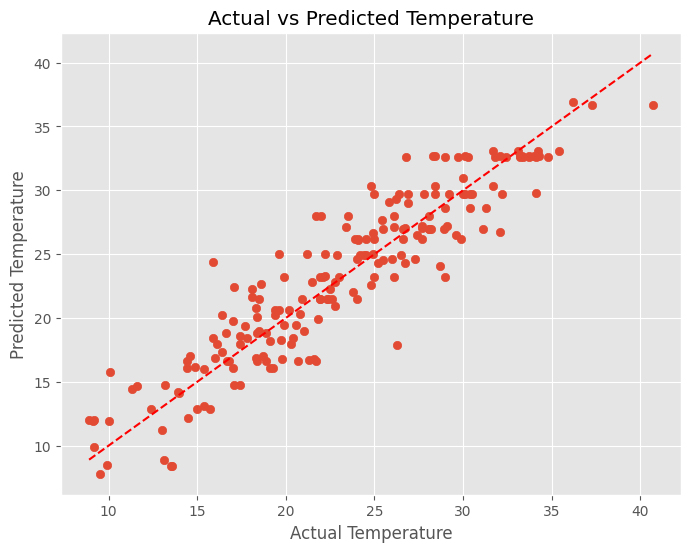

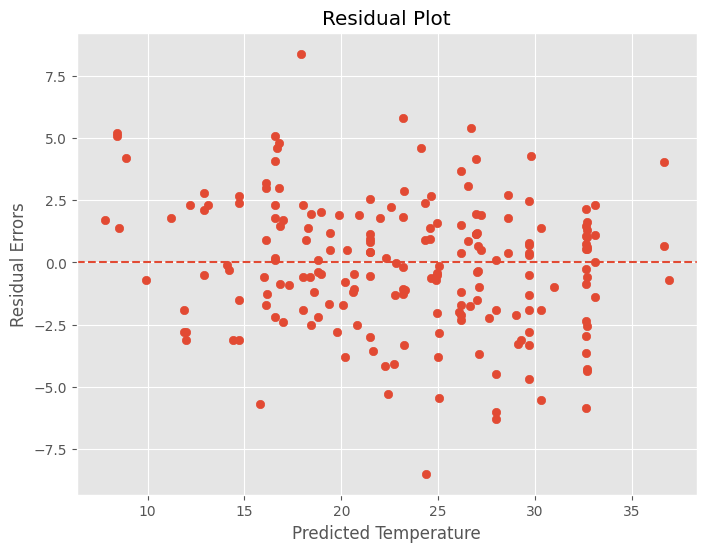


Model Evaluation Completed Successfully!


In [9]:
# ===========================================
# STEP 6: MODEL EVALUATION
# ===========================================

# Import Libraries
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# -------------------------------------------
# Calculate Evaluation Metrics
# -------------------------------------------

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)
accuracy = r2 * 100

print("========================================")
print("MODEL EVALUATION")
print("========================================")

print(f"Mean Absolute Error (MAE) : {mae:.2f}")
print(f"Mean Squared Error (MSE)  : {mse:.2f}")
print(f"Root Mean Squared Error   : {rmse:.2f}")
print(f"R² Score                  : {r2:.4f}")
print(f"Model Accuracy            : {accuracy:.2f}%")

# -------------------------------------------
# Actual vs Predicted Graph
# -------------------------------------------

plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)

plt.xlabel("Actual Temperature")
plt.ylabel("Predicted Temperature")
plt.title("Actual vs Predicted Temperature")

plt.show()

# -------------------------------------------
# Residual Plot
# -------------------------------------------

residuals = y_test - y_pred

plt.figure(figsize=(8,6))
plt.scatter(y_pred, residuals)

plt.axhline(y=0, linestyle='--')

plt.xlabel("Predicted Temperature")
plt.ylabel("Residual Errors")
plt.title("Residual Plot")

plt.show()

print("\nModel Evaluation Completed Successfully!")

In [11]:
# ===========================================
# STEP 7: SAVE THE TRAINED MODEL
# Temperature Prediction ML Project
# ===========================================

# Import Required Libraries
import joblib
import pandas as pd
from google.colab import files

# -------------------------------------------
# Save the Trained Model
# -------------------------------------------
model_filename = "temperature_prediction_model.pkl"

joblib.dump(model, model_filename)

print("==========================================")
print("Model Saved Successfully!")
print(f"Model File Name: {model_filename}")
print("==========================================")

# -------------------------------------------
# Load the Saved Model
# -------------------------------------------
loaded_model = joblib.load(model_filename)

print("\nSaved Model Loaded Successfully!")

# -------------------------------------------
# Predict Using Loaded Model
# -------------------------------------------
loaded_predictions = loaded_model.predict(X_test)

# -------------------------------------------
# Compare Actual vs Predicted Values
# -------------------------------------------
comparison = pd.DataFrame({
    "Actual Temperature": y_test.values,
    "Predicted Temperature": loaded_predictions
})

print("\nFirst 10 Predictions from Loaded Model:")
print(comparison.head(10))

# -------------------------------------------
# Save Prediction Results
# -------------------------------------------
comparison.to_excel("temperature_prediction_results.xlsx", index=False)

print("\nPrediction Results Saved Successfully!")
print("File Name: temperature_prediction_results.xlsx")

# -------------------------------------------
# Download Model File
# -------------------------------------------
files.download(model_filename)

# -------------------------------------------
# Download Prediction Results
# -------------------------------------------
files.download("temperature_prediction_results.xlsx")

print("\n==========================================")
print("STEP 7 COMPLETED SUCCESSFULLY")
print("Model Saved")
print("Model Verified")
print("Prediction Results Saved")
print("Files Downloaded")
print("==========================================")

Model Saved Successfully!
Model File Name: temperature_prediction_model.pkl

Saved Model Loaded Successfully!

First 10 Predictions from Loaded Model:
   Actual Temperature  Predicted Temperature
0                15.7              12.900000
1                11.6              14.700000
2                30.4              28.600000
3                29.0              28.600000
4                17.8              18.400000
5                33.4              32.648148
6                26.2              29.300000
7                18.3              20.800000
8                21.8              19.900000
9                26.9              29.708333

Prediction Results Saved Successfully!
File Name: temperature_prediction_results.xlsx


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


STEP 7 COMPLETED SUCCESSFULLY
Model Saved
Model Verified
Prediction Results Saved
Files Downloaded
